In [2]:
import sentencepiece as spm
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import os
import re
import random

# Функция очистки текста
def clean_text(text):
    if isinstance(text, str):
        text = re.sub(r'\n|\r|\t', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    return text

# Собираем все тексты в один файл для обучения токенизатора
print("Сбор всех текстов для обучения токенизатора...")

# Загружаем данные
df = pd.read_csv('train-kenlm.csv', usecols=['text', 'label'])
df['text'] = df['text'].fillna('').apply(clean_text)

# Фильтруем по длине
df['wc'] = df['text'].str.split().str.len()
df = df[df['wc'] >= 50].drop(columns='wc')

# Разделяем на human и ai
df_human = df[df['label'] == 'human']
df_ai = df[df['label'] != 'human']

# Фильтруем AI по моделям (>=700)
ai_models = df_ai['label'].value_counts()
models_to_keep = ai_models[ai_models >= 700].index
df_ai = df_ai[df_ai['label'].isin(models_to_keep)]

# Балансировка
n_samples = min(len(df_human), len(df_ai))
if len(df_human) > n_samples:
    df_human = df_human.sample(n_samples, random_state=42)
if len(df_ai) > n_samples:
    df_ai = df_ai.sample(n_samples, random_state=42)

# Объединяем все тексты для обучения токенизатора
all_texts = df_human['text'].tolist() + df_ai['text'].tolist()
with open('all_texts.txt', 'w', encoding='utf-8') as f:
    for text in all_texts:
        f.write(text + '\n')

print(f"Сохранено {len(all_texts)} текстов для обучения токенизатора")

Сбор всех текстов для обучения токенизатора...
Сохранено 14550 текстов для обучения токенизатора


In [ ]:
import sentencepiece as spm

# Обучение токенизатора
print("Обучение токенизатора SentencePiece...")

spm.SentencePieceTrainer.Train(
    input='all_texts.txt',
    model_prefix='tokenizer',
    vocab_size=16000,
    model_type='bpe',
    character_coverage=0.9995,
    max_sentence_length=10000
)

# Загрузка токенизатора
sp = spm.SentencePieceProcessor()
sp.load('tokenizer.model')

print(f"Токенизатор обучен. Размер словаря: {sp.get_piece_size()}")

In [18]:
def sp_tokenize(text):
    """Токенизация текста через SentencePiece"""
    pieces = sp.encode(text, out_type=str)
    return ' '.join(pieces)

# Функция обрезки текста
def truncate_text(text, max_words=300):
    words = text.split()
    if len(words) > max_words:
        words = words[:max_words]
    return ' '.join(words)

# Загружаем данные заново
df = pd.read_csv('train-kenlm.csv', usecols=['text', 'label'])
df['text'] = df['text'].fillna('').apply(clean_text)

# Фильтруем по длине
df['wc'] = df['text'].str.split().str.len()
df = df[df['wc'] >= 50].drop(columns='wc').reset_index(drop=True)

df_human = df[df['label'] == 'human']
df_ai = df[df['label'] != 'human']

# Фильтрация по моделям
ai_models = df_ai['label'].value_counts()
models_to_keep = ai_models[ai_models >= 700].index
df_ai = df_ai[df_ai['label'].isin(models_to_keep)]

human_texts = df_human['text'].tolist()
ai_texts = df_ai['text'].tolist()

# Балансировка
n_samples = min(len(human_texts), len(ai_texts))
print(f"Балансировка: берем {n_samples} текстов каждого класса")

if len(ai_texts) > n_samples:
    ai_texts = random.sample(ai_texts, n_samples)
else:
    human_texts = random.sample(human_texts, n_samples)

# Обрезка текстов
print("Применяем обрезку до 300 слов...")
human_texts = [truncate_text(t, max_words=300) for t in human_texts]
ai_texts = [truncate_text(t, max_words=300) for t in ai_texts]

print("Применяем токенизацию SentencePiece...")
human_texts = [sp_tokenize(t) for t in human_texts]
ai_texts = [sp_tokenize(t) for t in ai_texts]

# Разделение 70/15/15
human_train, human_temp = train_test_split(human_texts, test_size=0.3, random_state=42, shuffle=True)
human_val, human_test = train_test_split(human_temp, test_size=0.5, random_state=42, shuffle=True)

ai_train, ai_temp = train_test_split(ai_texts, test_size=0.3, random_state=42, shuffle=True)
ai_val, ai_test = train_test_split(ai_temp, test_size=0.5, random_state=42, shuffle=True)

print(f"\nРазделение (сбалансированное):")
print(f"  Обучение: human={len(human_train)}, ai={len(ai_train)}")
print(f"  Валидация: human={len(human_val)}, ai={len(ai_val)}")
print(f"  Тест: human={len(human_test)}, ai={len(ai_test)}")

# Сохраняем файлы
for f in ['train_texts.txt', 'val_human.txt', 'val_ai.txt', 'test_human.txt', 'test_ai.txt']:
    if os.path.exists(f):
        os.remove(f)

with open('train_texts.txt', 'w', encoding='utf-8') as f:
    for text in human_train + ai_train:
        f.write(text + '\n')

with open('val_human.txt', 'w', encoding='utf-8') as f:
    for text in human_val:
        f.write(text + '\n')

with open('val_ai.txt', 'w', encoding='utf-8') as f:
    for text in ai_val:
        f.write(text + '\n')

with open('test_human.txt', 'w', encoding='utf-8') as f:
    for text in human_test:
        f.write(text + '\n')

with open('test_ai.txt', 'w', encoding='utf-8') as f:
    for text in ai_test:
        f.write(text + '\n')

print("\nФайлы с токенизированными текстами сохранены:")
print(f"  train_texts.txt: {len(human_train)+len(ai_train)} текстов")
print(f"  val_human.txt: {len(human_val)} текстов")
print(f"  val_ai.txt: {len(ai_val)} текстов")
print(f"  test_human.txt: {len(human_test)} текстов")
print(f"  test_ai.txt: {len(ai_test)} текстов")

Балансировка: берем 7275 текстов каждого класса
Применяем обрезку до 300 слов...
Применяем токенизацию SentencePiece...

Разделение (сбалансированное):
  Обучение: human=5092, ai=5092
  Валидация: human=1091, ai=1091
  Тест: human=1092, ai=1092

Файлы с токенизированными текстами сохранены:
  train_texts.txt: 10184 текстов
  val_human.txt: 1091 текстов
  val_ai.txt: 1091 текстов
  test_human.txt: 1092 текстов
  test_ai.txt: 1092 текстов


In [19]:
import os
import subprocess

bin_path = os.path.abspath("kenlm-master/build/bin")
lmplz_path = os.path.join(bin_path, "lmplz")
build_binary_path = os.path.join(bin_path, "build_binary")

print("Обучение KenLM модели...")

!{lmplz_path} -o 3 < train_texts.txt > model.arpa
!{build_binary_path} model.arpa model.binary

!ls -lh model.arpa model.binary

import kenlm
model = kenlm.Model('model.binary')
print("Модель успешно загружена!")

Обучение KenLM модели...
=== 1/5 Counting and sorting n-grams ===
Reading /workspace/cloud/experiments/train_texts.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 2346658 types 4214
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:50568 2:1142554112 3:2142289024
Statistics:
1 4214 D1=0.555556 D2=0.27957 D3+=0.8125
2 399296 D1=0.679209 D2=1.16296 D3+=1.53205
3 1220322 D1=0.761928 D2=1.14275 D3+=1.42258
Memory estimate for binary LM:
type       kB
probing 30916 assuming -p 1.5
probing 33272 assuming -r models -p 1.5
trie    11381 without quantization
trie     5667 assuming -q 8 -b 8 quantization 
trie    10773 assuming -a 22 array pointer compression
trie     5059 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes:

In [20]:
def get_perplexity(model, text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None
    try:
        log_prob = model.score(text)
        words = text.split()
        return 2.0 ** (-log_prob / len(words)) if words else None
    except:
        return None

In [21]:
import numpy as np
with open('val_human.txt', 'r', encoding='utf-8') as f:
    val_human = [line.strip() for line in f.readlines() if line.strip()]

with open('val_ai.txt', 'r', encoding='utf-8') as f:
    val_ai = [line.strip() for line in f.readlines() if line.strip()]

print(f"Валидация: human={len(val_human)}, ai={len(val_ai)}")

val_human_ppl = [get_perplexity(model, text) for text in val_human]
val_human_ppl = [x for x in val_human_ppl if x is not None]

val_ai_ppl = [get_perplexity(model, text) for text in val_ai]
val_ai_ppl = [x for x in val_ai_ppl if x is not None]

print(f"  Среднее ppl human: {np.mean(val_human_ppl):.2f}")
print(f"  Среднее ppl ai: {np.mean(val_ai_ppl):.2f}")

Валидация: human=1091, ai=1091
  Среднее ppl human: 3.39
  Среднее ppl ai: 2.90


Accuracy порог: 3.14 (acc=0.7841)
F1 порог:       3.23 (f1=0.7944)
AUC порог:   3.15 (auc=0.8496)


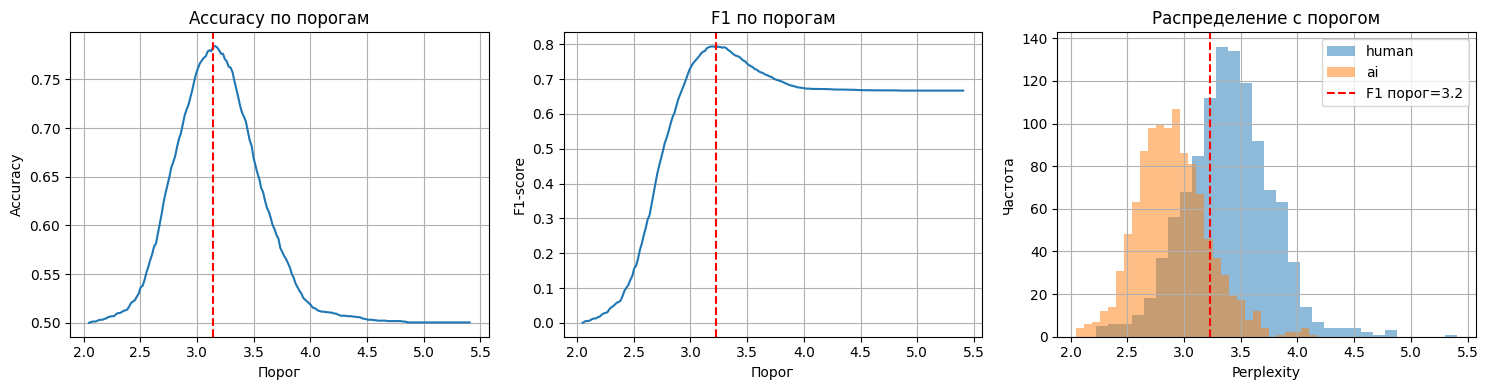

In [22]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

all_ppl = np.array(val_human_ppl + val_ai_ppl)
y_true = [0] * len(val_human_ppl) + [1] * len(val_ai_ppl)

thresholds = np.linspace(min(all_ppl), max(all_ppl), 200)

best_acc = 0
best_thresh_acc = None
acc_scores = []

for thresh in thresholds:
    y_pred = [1 if ppl < thresh else 0 for ppl in all_ppl]
    acc = accuracy_score(y_true, y_pred)
    acc_scores.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_thresh_acc = thresh

best_f1 = 0
best_thresh_f1 = None
f1_scores = []

for thresh in thresholds:
    y_pred = [1 if ppl < thresh else 0 for ppl in all_ppl]
    f1 = f1_score(y_true, y_pred)
    f1_scores.append(f1)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh_f1 = thresh

y_score = -all_ppl
val_auc = roc_auc_score(y_true, y_score)
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
youden = tpr - fpr
best_idx = np.argmax(youden)
best_thresh_youden = -roc_thresholds[best_idx]
best_youden = youden[best_idx]

print(f"Accuracy порог: {best_thresh_acc:.2f} (acc={best_acc:.4f})")
print(f"F1 порог:       {best_thresh_f1:.2f} (f1={best_f1:.4f})")
print(f"AUC порог:   {best_thresh_youden:.2f} (auc={val_auc:.4f})")

# Визуализация
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(thresholds, acc_scores)
plt.axvline(best_thresh_acc, color='red', linestyle='--')
plt.xlabel('Порог')
plt.ylabel('Accuracy')
plt.title('Accuracy по порогам')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(thresholds, f1_scores)
plt.axvline(best_thresh_f1, color='red', linestyle='--')
plt.xlabel('Порог')
plt.ylabel('F1-score')
plt.title('F1 по порогам')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.hist(val_human_ppl, bins=30, alpha=0.5, label='human')
plt.hist(val_ai_ppl, bins=30, alpha=0.5, label='ai')
plt.axvline(best_thresh_f1, color='red', linestyle='--', label=f'F1 порог={best_thresh_f1:.1f}')
plt.xlabel('Perplexity')
plt.ylabel('Частота')
plt.title('Распределение с порогом')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
with open('test_human.txt', 'r', encoding='utf-8') as f:
    test_human = [line.strip() for line in f.readlines() if line.strip()]

with open('test_ai.txt', 'r', encoding='utf-8') as f:
    test_ai = [line.strip() for line in f.readlines() if line.strip()]

print(f"Тест: human={len(test_human)}, ai={len(test_ai)}")

test_human_ppl = [get_perplexity(model, text) for text in test_human]
test_human_ppl = [x for x in test_human_ppl if x is not None]

test_ai_ppl = [get_perplexity(model, text) for text in test_ai]
test_ai_ppl = [x for x in test_ai_ppl if x is not None]

print(f"\nТестовая перплексия:")
print(f"  Human среднее: {np.mean(test_human_ppl):.2f}")
print(f"  Llama среднее: {np.mean(test_ai_ppl):.2f}")

Тест: human=1092, ai=1092

Тестовая перплексия:
  Human среднее: 3.40
  Llama среднее: 2.88


In [24]:
test_all_ppl = np.array(test_human_ppl + test_ai_ppl)
y_test_true = [0] * len(test_human_ppl) + [1] * len(test_ai_ppl)

final_threshold = best_thresh_acc
y_test_pred = [1 if ppl < final_threshold else 0 for ppl in test_all_ppl]

print(f"Используем порог по Acc: {final_threshold:.2f}")
print(f"Предсказано machine: {sum(y_test_pred)} из {len(y_test_pred)}")

Используем порог по Acc: 3.14
Предсказано machine: 1153 из 2184


In [25]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

test_acc = accuracy_score(y_test_true, y_test_pred)
test_f1 = f1_score(y_test_true, y_test_pred)
test_auc = roc_auc_score(y_test_true, -test_all_ppl)

print(f"Accuracy:  {test_acc:.4f}")
print(f"F1-score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_auc:.4f}")

cm = confusion_matrix(y_test_true, y_test_pred)
print("\nМатрица ошибок:")
print("           Pred human  Pred machine")
print(f"Actual human    {cm[0,0]:5d}      {cm[0,1]:5d}")
print(f"Actual machine  {cm[1,0]:5d}      {cm[1,1]:5d}")

Accuracy:  0.7972
F1-score:  0.8027
ROC-AUC:   0.8679

Матрица ошибок:
           Pred human  Pred machine
Actual human      840        252
Actual machine    191        901


In [26]:
print(f"{'Метрика':<12} {'Валидация':>10} {'Тест':>10} {'Разница':>10}")
print("-"*50)
print(f"{'F1-score':<12} {best_f1:>10.4f} {test_f1:>10.4f} {test_f1 - best_f1:>+10.4f}")
print(f"{'Accuracy':<12} {best_acc:>10.4f} {test_acc:>10.4f} {test_acc - best_acc:>+10.4f}")
print(f"{'ROC-AUC':<12} {val_auc:>10.4f} {test_auc:>10.4f} {test_auc - val_auc:>+10.4f}")

Метрика       Валидация       Тест    Разница
--------------------------------------------------
F1-score         0.7944     0.8027    +0.0082
Accuracy         0.7841     0.7972    +0.0130
ROC-AUC          0.8496     0.8679    +0.0183


/tmp/ipykernel_4160/810686892.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['human', 'ai'], patch_artist=True)


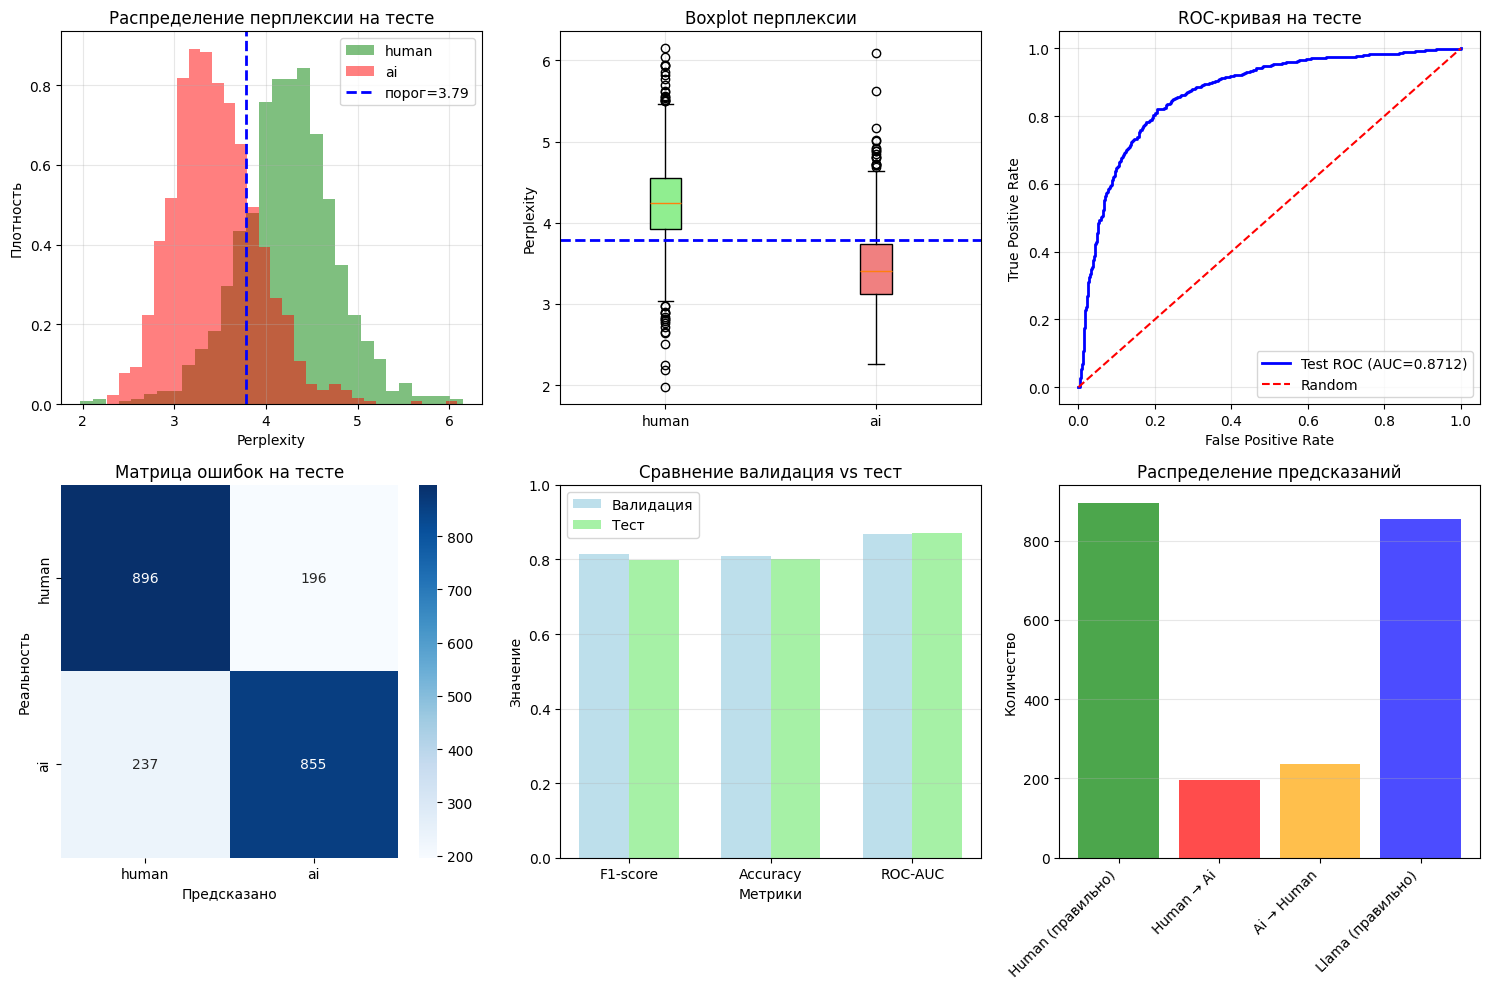


Итоговые метрики на тесте (порог F1=3.79):
  Accuracy: 0.8017
  F1-score: 0.7979
  ROC-AUC:  0.8712


In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns

test_machine_ppl = test_ai_ppl
y_test_true = [0]*len(test_human_ppl) + [1]*len(test_machine_ppl)
y_test_score = -np.array(test_human_ppl + test_machine_ppl)

plt.figure(figsize=(15, 10))

# 1. Распределение перплексии на тесте
plt.subplot(2, 3, 1)
plt.hist(test_human_ppl, bins=30, alpha=0.5, label='human', density=True, color='green')
plt.hist(test_machine_ppl, bins=30, alpha=0.5, label='ai', density=True, color='red')
plt.axvline(x=final_threshold, color='blue', linestyle='--', linewidth=2, 
            label=f'порог={final_threshold:.2f}')
plt.xlabel('Perplexity')
plt.ylabel('Плотность')
plt.title('Распределение перплексии на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Boxplot
plt.subplot(2, 3, 2)
data_to_plot = [test_human_ppl, test_machine_ppl]
bp = plt.boxplot(data_to_plot, labels=['human', 'ai'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
plt.axhline(y=final_threshold, color='blue', linestyle='--', linewidth=2)
plt.ylabel('Perplexity')
plt.title('Boxplot перплексии')
plt.grid(True, alpha=0.3)

# 3. ROC-кривая
plt.subplot(2, 3, 3)
fpr_test, tpr_test, _ = roc_curve(y_test_true, y_test_score)
plt.plot(fpr_test, tpr_test, 'b-', linewidth=2, label=f'Test ROC (AUC={test_auc:.4f})')
plt.plot([0,1], [0,1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Матрица ошибок
plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['human', 'ai'], 
            yticklabels=['human', 'ai'])
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('Матрица ошибок на тесте')

# 5. Сравнение метрик валидация vs тест
plt.subplot(2, 3, 5)
metrics = ['F1-score', 'Accuracy', 'ROC-AUC']
val_values = [best_f1, best_acc, val_auc]
test_values = [test_f1, test_acc, test_auc]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, val_values, width, label='Валидация', color='lightblue', alpha=0.8)
plt.bar(x + width/2, test_values, width, label='Тест', color='lightgreen', alpha=0.8)
plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение валидация vs тест')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1])

# 6. Предсказания по классам
plt.subplot(2, 3, 6)
labels = ['Human (правильно)', 'Human → Ai', 'Ai → Human', 'Llama (правильно)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['green', 'red', 'orange', 'blue']
plt.bar(labels, values, color=colors, alpha=0.7)
plt.ylabel('Количество')
plt.title('Распределение предсказаний')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nИтоговые метрики на тесте (порог F1={final_threshold:.2f}):")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  F1-score: {test_f1:.4f}")
print(f"  ROC-AUC:  {test_auc:.4f}")